<a href="https://colab.research.google.com/github/ancestor9/mathematics-for-machine-learning/blob/main/scripts/cell_contamination.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import warnings
warnings.filterwarnings('ignore')

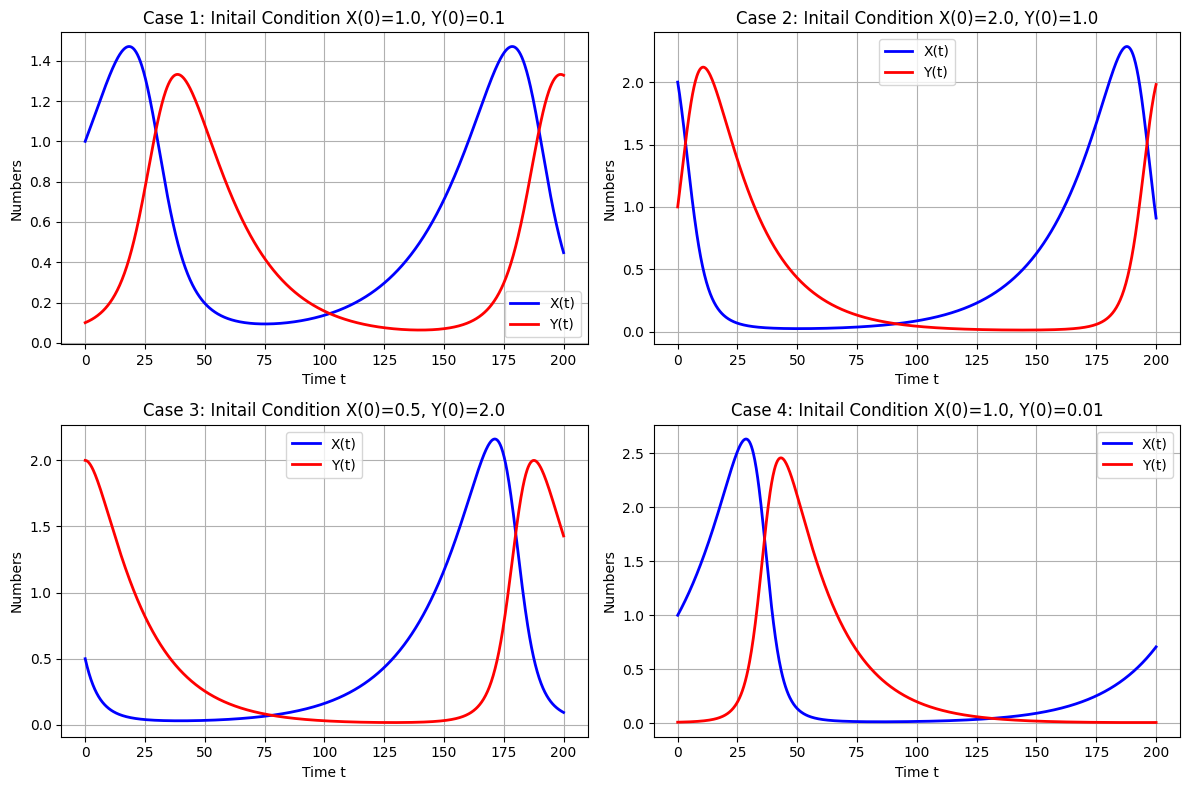

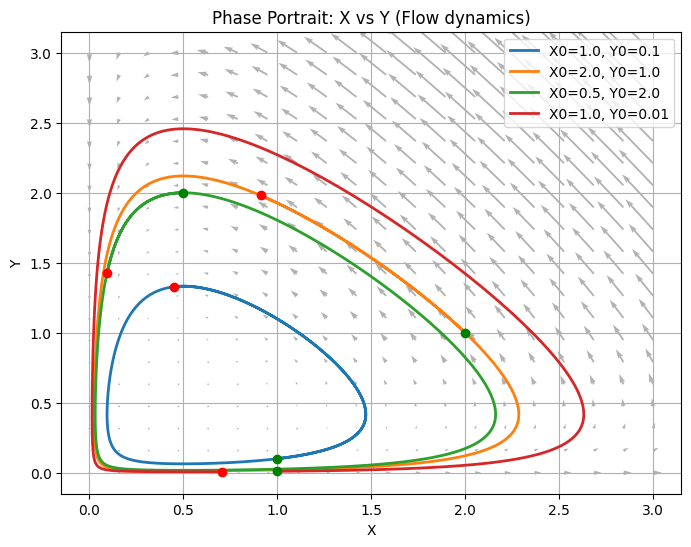

In [2]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# ==================== 모델 정의 ====================
def model(state, t, k, d):
    X, Y = state
    dXdt = X / 24 - k * X * Y          # X의 변화율
    dYdt = k * X * Y - d * Y           # Y의 변화율
    return [dXdt, dYdt]

# ==================== 파라미터 설정 ====================
k = 0.1      # X + Y → Y + Y 반응 속도 (상호작용 강도)
d = 0.05     # Y → 소멸 속도 (Y의 사멸률)
t = np.linspace(0, 200, 1000)   # 시간 범위 (0부터 200까지)

# ==================== 초기 조건 ====================
initial_conditions = [
    [1.0, 0.1],    # Case 1: X 많고 Y 적음
    [2.0, 1.0],    # Case 2: 균형에 가까움
    [0.5, 2.0],    # Case 3: Y가 이미 많음
    [1.0, 0.01]    # Case 4: Y가 매우 적음
]

# ==================== 1. 시간에 따른 변화 그래프 ====================
plt.figure(figsize=(12, 8))

for i, (X0, Y0) in enumerate(initial_conditions, 1):
    sol = odeint(model, [X0, Y0], t, args=(k, d))
    X = sol[:, 0]
    Y = sol[:, 1]

    plt.subplot(2, 2, i)
    plt.plot(t, X, 'b-', label='X(t)', linewidth=2)
    plt.plot(t, Y, 'r-', label='Y(t)', linewidth=2)
    plt.xlabel('Time t')
    plt.ylabel('Numbers')
    plt.title(f'Case {i}: Initail Condition X(0)={X0}, Y(0)={Y0}')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

# ==================== 2. 위상평면 그래프 (Phase Portrait) ====================
plt.figure(figsize=(8, 6))

for X0, Y0 in initial_conditions:
    sol = odeint(model, [X0, Y0], t, args=(k, d))
    X = sol[:, 0]
    Y = sol[:, 1]
    plt.plot(X, Y, linewidth=2, label=f'X0={X0}, Y0={Y0}')
    plt.plot(X[0], Y[0], 'go')   # 시작점
    plt.plot(X[-1], Y[-1], 'ro') # 끝점

# 흐름장 (quiver) 추가
x = np.linspace(0, 3, 20)
y = np.linspace(0, 3, 20)
Xg, Yg = np.meshgrid(x, y)
dX = Xg/24 - k*Xg*Yg
dY = k*Xg*Yg - d*Yg
plt.quiver(Xg, Yg, dX, dY, color='gray', alpha=0.6)

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Phase Portrait: X vs Y (Flow dynamics)')
plt.legend()
plt.grid(True)
plt.show()

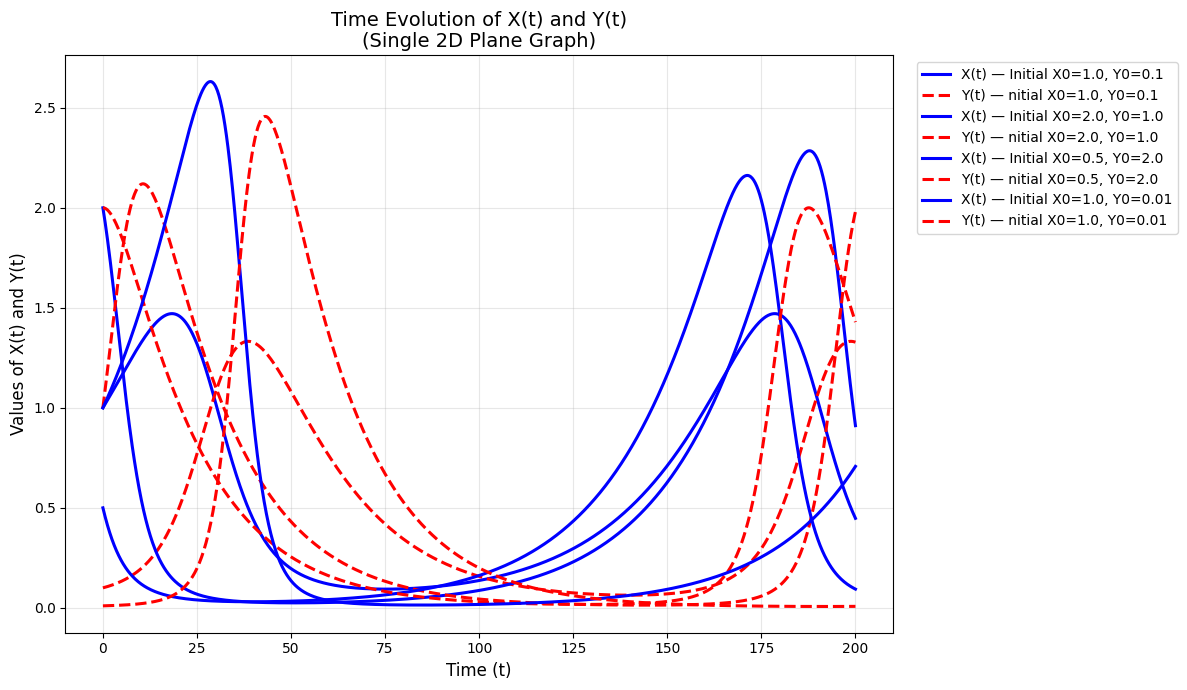

In [13]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# ==================== 모델 정의 ====================
def model(state, t, k, d):
    X, Y = state
    dXdt = X / 24 - k * X * Y      # X의 변화율
    dYdt = k * X * Y - d * Y       # Y의 변화율
    return [dXdt, dYdt]

# ==================== 파라미터 ====================
k = 0.1      # X+Y → Y+Y 반응 속도
d = 0.05     # Y 소멸 속도
t = np.linspace(0, 200, 1000)   # 시간 범위 (0 ~ 200)

# ==================== 초기 조건들 ====================
initial_conditions = [
    [1.0, 0.1],    # Case 1
    [2.0, 1.0],    # Case 2
    [0.5, 2.0],    # Case 3
    [1.0, 0.01]    # Case 4
]

# ==================== 그래프 그리기 ====================
plt.figure(figsize=(12, 7))

for X0, Y0 in initial_conditions:
    # 미분방정식 수치 해
    sol = odeint(model, [X0, Y0], t, args=(k, d))
    X = sol[:, 0]
    Y = sol[:, 1]

    plt.plot(t, X, 'b-', linewidth=2.2, label=f'X(t) — Initial X0={X0}, Y0={Y0}')
    plt.plot(t, Y, 'r--', linewidth=2.2, label=f'Y(t) — nitial X0={X0}, Y0={Y0}')

plt.xlabel('Time (t)', fontsize=12)
plt.ylabel('Values of X(t) and Y(t)', fontsize=12)
plt.title('Time Evolution of X(t) and Y(t)\n(Single 2D Plane Graph)', fontsize=14)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

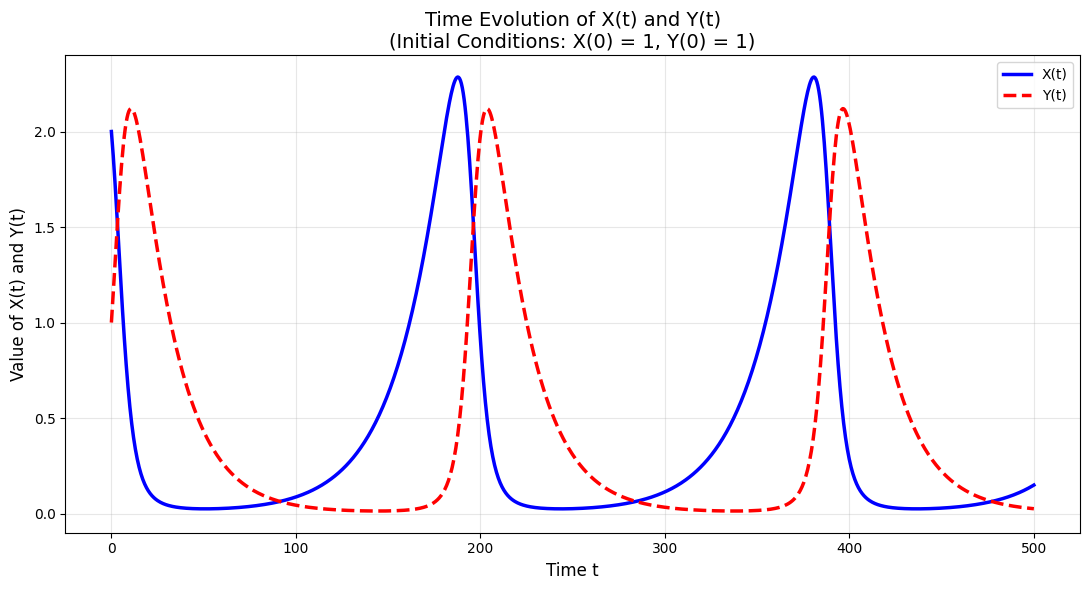

Final values at t=200:
X(200) ≈ 0.1494
Y(200) ≈ 0.0256


In [4]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# ==================== Model Definition ====================
def model(state, t, k, d):
    X, Y = state
    dXdt = X / 24 - k * X * Y      # Rate of change for X
    dYdt = k * X * Y - d * Y       # Rate of change for Y
    return [dXdt, dYdt]

# ==================== Parameters ====================
k = 0.1      # Reaction rate for X + Y → Y + Y
d = 0.05     # Decay rate of Y
t = np.linspace(0, 500, 1000)   # Time range: 0 to 200

# ==================== Initial Condition ====================
X0 = 2.0
Y0 = 1.0

# ==================== Solve ODE ====================
sol = odeint(model, [X0, Y0], t, args=(k, d))
X = sol[:, 0]
Y = sol[:, 1]

# ==================== Plot ====================
plt.figure(figsize=(11, 6))

plt.plot(t, X, 'b-', linewidth=2.5, label='X(t)')
plt.plot(t, Y, 'r--', linewidth=2.5, label='Y(t)')

plt.xlabel('Time t', fontsize=12)
plt.ylabel('Value of X(t) and Y(t)', fontsize=12)
plt.title('Time Evolution of X(t) and Y(t)\n(Initial Conditions: X(0) = 1, Y(0) = 1)',
          fontsize=14)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print final values
print(f"Final values at t=200:")
print(f"X(200) ≈ {X[-1]:.4f}")
print(f"Y(200) ≈ {Y[-1]:.4f}")

미분방정식: Eq(Derivative(y(x), x), k*(1 - y(x)/K)*y(x))

일반해 (상수 포함): Eq(y(x), K*exp(C1*K + k*x)/(exp(C1*K + k*x) - 1))

특수해 (k=0.3, K=2.0, y(1)=1): Eq(y(x), 2.0/(1 + 1.349858807576*exp(-0.3*x)))


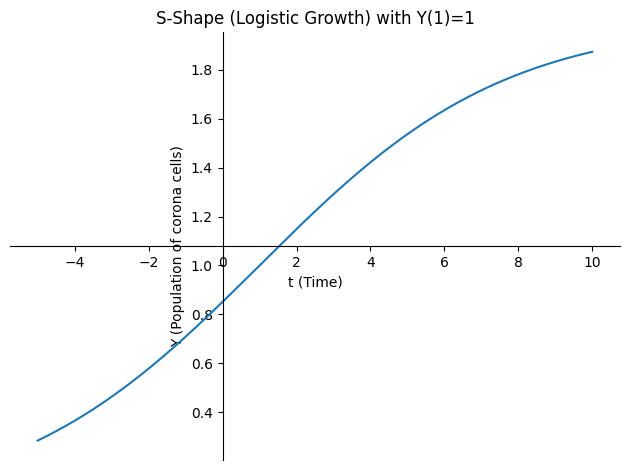

In [6]:
import sympy
from sympy.plotting import plot

# 변수 및 함수 정의
x = sympy.Symbol('x')  # 시간 (t)
y = sympy.Function('y')(x)  # 감염자 수 (y(t))

# 로지스틱 미분방정식 정의
k = sympy.Symbol('k')  # 성장 상수
K = sympy.Symbol('K')  # 수용 한계
ode = sympy.Eq(y.diff(x), k * y * (1 - y/K))

print(f"미분방정식: {ode}")

# 일반해 구하기 (ics 없이)
general_solution_eq = sympy.dsolve(ode, y)
print(f"\n일반해 (상수 포함): {general_solution_eq}")

# 사용자 요청 초기값: (1, 1) 적용
k_val = 0.3
K_val = 2.0
initial_x = 1
initial_y = 1

# SymPy의 dsolve가 0 < y < K 조건에서 특정 일반해 형태에 대해 ics를 잘 처리하지 못하므로,
# 보다 일반적인 로지스틱 성장 모델의 해 형태를 사용하고 상수를 수동으로 구합니다.
# 일반적인 로지스틱 성장 모델의 해는 y(x) = K / (1 + C * exp(-k*x)) 입니다.
C_sym = sympy.Symbol('C')
common_logistic_sol_rhs = K / (1 + C_sym * sympy.exp(-k * x))

# 초기 조건을 대입하여 C 값 구하기
equation_for_C = sympy.Eq(initial_y, common_logistic_sol_rhs.subs({
    x: initial_x,
    k: k_val,
    K: K_val
}))

solutions_C = sympy.solve(equation_for_C, C_sym)

if solutions_C:
    C_val = solutions_C[0]
    # 특수해 정의
    particular_solution_rhs = common_logistic_sol_rhs.subs({C_sym: C_val, k: k_val, K: K_val})
    particular_solution_eq = sympy.Eq(y, particular_solution_rhs)
    print(f"\n특수해 (k={k_val}, K={K_val}, y({initial_x})={initial_y}): {particular_solution_eq}")

    # 그래프 시각화
    p = plot(particular_solution_rhs, (x, -5, 10),
             title=f"S-Shape (Logistic Growth) with Y({initial_x})={initial_y}",
             xlabel="t (Time)", ylabel="Y (Population of corona cells)",
             show=False)
    p.show()
else:
    print("오류: 주어진 초기 조건에 대해 로지스틱 방정식의 상수 C를 찾을 수 없습니다.")

ParameterSymbolRole in S-shapeEffect of IncreasingGrowth Rate$k$Determines the steepness of the curve.The "S" becomes sharper and more vertical.Carrying Capacity$K$The ceiling or maximum value the curve can reach.The curve plateaus at a higher level.Initial Value$y(t_0)$The starting point of the infection/diffusion.If high, you only see the top half of the "S".Time Offset$t$Moves the curve left or right on the axis.Shifting the center of the "S" curve.

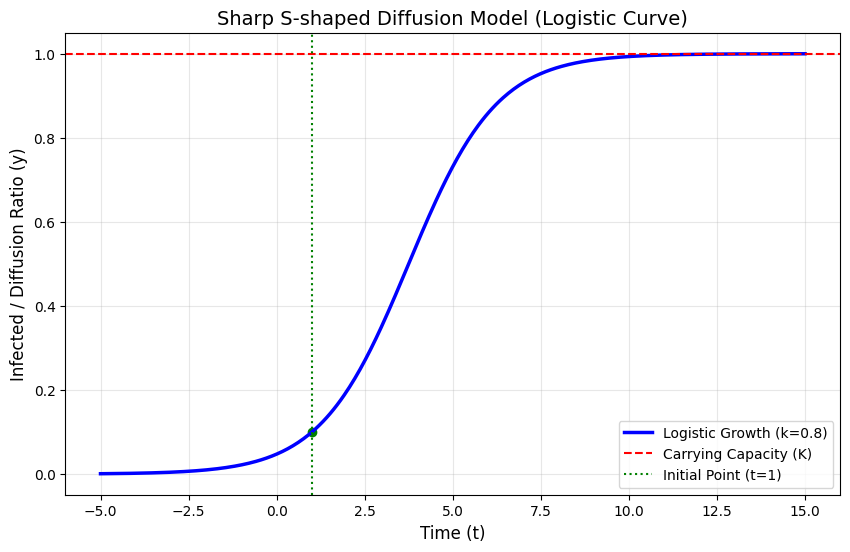

In [9]:
import sympy
import numpy as np
import matplotlib.pyplot as plt

# 1. Symbolic Setup
t = sympy.Symbol('t')
y = sympy.Function('y')(t)
k, K = sympy.symbols('k K')

# Logistic ODE: dy/dt = k*y*(1 - y/K)
logistic_ode = sympy.Eq(y.diff(t), k * y * (1 - y/K))

# 2. Parameters for "Sharp" S-shape
k_val = 0.8  # Higher growth rate for sharper curve
K_val = 1.0  # Carrying capacity (Max value)
t_init, y_init = 1, 0.1 # Starting point (Initial condition)

# 3. Solve ODE with Initial Condition
# Note: Initial value (1, 1) in your previous request makes it start at the top.
# For a clear S-shape, the initial y should be small (e.g., 0.1).
particular_sol = sympy.dsolve(logistic_ode.subs({k: k_val, K: K_val}),
                              y, ics={y.subs(t, t_init): y_init})

# 4. Conversion to Numerical for High-Quality Plotting
f_numerical = sympy.lambdify(t, particular_sol.rhs, 'numpy')
t_vals = np.linspace(-5, 15, 400)
y_vals = f_numerical(t_vals)

# 5. Visualization (English)
plt.figure(figsize=(10, 6))
plt.plot(t_vals, y_vals, label=f'Logistic Growth (k={k_val})', color='blue', linewidth=2.5)
plt.axhline(y=K_val, color='red', linestyle='--', label='Carrying Capacity (K)')
plt.axvline(x=t_init, color='green', linestyle=':', label='Initial Point (t=1)')
plt.scatter([t_init], [y_init], color='green') # Mark the initial point

plt.title("Sharp S-shaped Diffusion Model (Logistic Curve)", fontsize=14)
plt.xlabel("Time (t)", fontsize=12)
plt.ylabel("Infected / Diffusion Ratio (y)", fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

--- Model Parameters ---
Total Population (K): 51,410,000
Growth Rate (k): 0.35
Initial Infected (Y0): 1
---------------


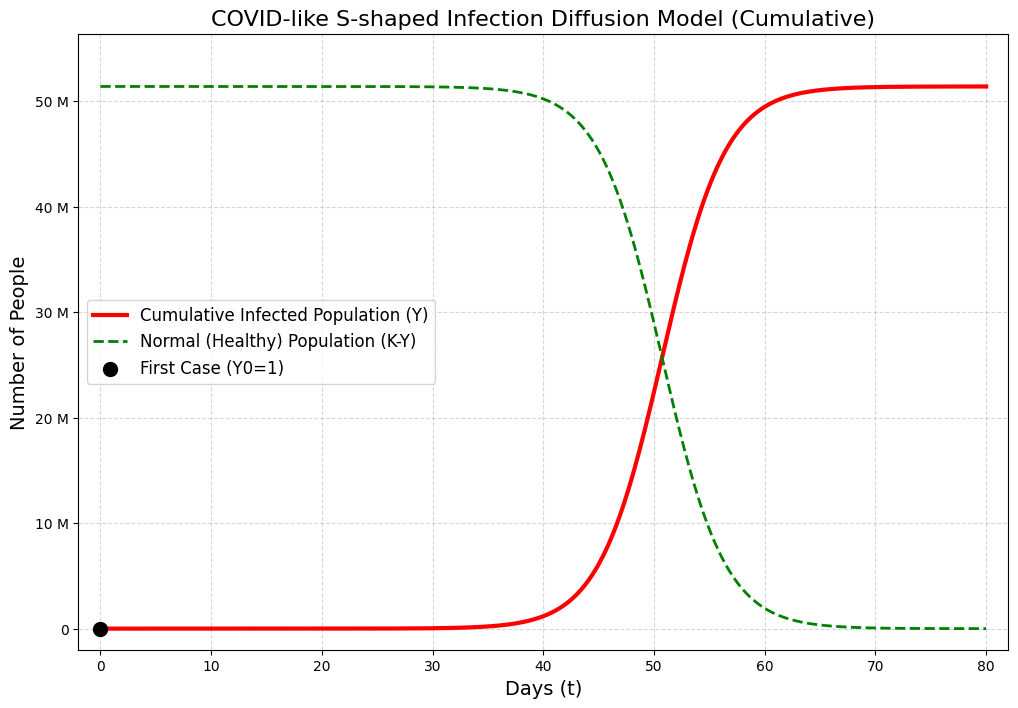

In [11]:
import sympy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. Symbolic Setup
t = sympy.Symbol('t')
Y_sym = sympy.Function('Y')(t)
k, K, C_const = sympy.symbols('k K C_const')

# Logistic ODE for cumulative infections
# logistic_ode = sympy.Eq(Y_sym.diff(t), k * Y_sym * (1 - Y_sym/K)) # Not directly used for solving here

# 2. Real-world Parameters (Hypothetical COVID-like scenario)
# Data source: Approximate South Korea population and rough infection rates
K_val = 51_410_000  # Total population of South Korea
k_val = 0.35        # Growth rate (steeper curve for rapid spread)
Y_init_val = 1     # Initial number of infected people (first case)
t_init_val = 0     # Start time of observation

print(f"--- Model Parameters ---")
print(f"Total Population (K): {K_val:,}")
print(f"Growth Rate (k): {k_val}")
print(f"Initial Infected (Y0): {Y_init_val}")
print(f"---" * 5)

# 3. Solve ODE with Initial Condition (Manual approach due to SymPy's dsolve limitation)
# The known analytical solution for logistic growth is Y(t) = K / (1 + C * exp(-k*t))
# We need to find C using initial conditions: Y(t_init_val) = Y_init_val

# Calculate the constant C
# Y_init_val = K_val / (1 + C * exp(-k_val * t_init_val))
# 1 + C * exp(-k_val * t_init_val) = K_val / Y_init_val
# C * exp(-k_val * t_init_val) = (K_val / Y_init_val) - 1
C_val = (K_val / Y_init_val - 1) * np.exp(k_val * t_init_val)

# Construct the particular solution using the calculated C
particular_sol_rhs = K / (1 + C_const * sympy.exp(-k * t))
particular_sol_rhs = particular_sol_rhs.subs({
    k: k_val,
    K: K_val,
    C_const: C_val
})

# 4. Conversion to Numerical for Plotting
# lambdify makes the symbolic expression a numerical function
y_numerical_func = sympy.lambdify(t, particular_sol_rhs, 'numpy')

# Time axis: 0 to 80 days
t_vals = np.linspace(0, 80, 500)
y_vals = y_numerical_func(t_vals)

# 5. Visualizing Normal (Healthy) Population
normal_vals = K_val - y_vals

# 6. Visualization (English)
plt.figure(figsize=(12, 8))

# Plot cumulative infections (Red, S-shape)
plt.plot(t_vals, y_vals, label='Cumulative Infected Population (Y)', color='red', linewidth=3)

# Plot healthy population (Green, inverted S-shape)
plt.plot(t_vals, normal_vals, label='Normal (Healthy) Population (K-Y)', color='green', linestyle='--', linewidth=2)

# Mark the initial point
plt.scatter([t_init_val], [Y_init_val], color='black', s=100, zorder=5, label='First Case (Y0=1)')

# Graph formatting
plt.title("COVID-like S-shaped Infection Diffusion Model (Cumulative)", fontsize=16)
plt.xlabel("Days (t)", fontsize=14)
plt.ylabel("Number of People", fontsize=14)

# Y-axis formatter for millions
plt.gca().yaxis.set_major_formatter(ticker.EngFormatter()) # Use Engineering formatter (e.g., 10M, 20M)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='best', fontsize=12)

# Set axis limits for clarity
plt.xlim(-2, 82)
plt.ylim(-2_000_000, K_val + 5_000_000) # Give some space above total population

plt.show()